In [11]:
# =============================================================
# Setup: Load saved data
# =============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

data_dir = os.path.expanduser(
    '~/Desktop/tariff-shock-tracker/data/raw')

us_df  = pd.read_csv(f'{data_dir}/us_stocks_crsp.csv',
                     parse_dates=['date'])
mkt_df = pd.read_csv(f'{data_dir}/us_market_index_crsp.csv',
                     parse_dates=['date'])
cn_df  = pd.read_csv(f'{data_dir}/cn_stocks_csmar.csv',
                     parse_dates=['date'])
cn_mkt_df = pd.read_csv(
    f'{data_dir}/cn_market_index_csmar.csv',
    parse_dates=['date'])

EVENT_DATE = pd.Timestamp('2024-05-14')

print("✅ Data loaded:")
print(f"   US stocks  : {us_df.shape}  | "
      f"Tickers: {sorted(us_df['ticker'].unique())}")
print(f"   US market  : {mkt_df.shape}")
print(f"   CN stocks  : {cn_df.shape}  | "
      f"Stocks: {sorted(cn_df['stkcd'].unique())}")
print(f"   CN market  : {cn_mkt_df.shape}")
print(f"\n   Event date : {EVENT_DATE.date()}")


✅ Data loaded:
   US stocks  : (1155, 8)  | Tickers: ['AAPL', 'GM', 'NVDA', 'TSLA', 'WMT']
   US market  : (231, 4)
   CN stocks  : (1110, 7)  | Stocks: [np.int64(333), np.int64(2475), np.int64(2594), np.int64(300750), np.int64(600519)]
   CN market  : (444, 4)

   Event date : 2024-05-14


In [12]:
# =============================================================
# Core Function: Event Study (Market Model)
# ============================================================

def run_event_study(stock_returns, market_returns,
                    event_date,
                    est_window=120,
                    est_gap=30,
                    event_pre=5,
                    event_post=10):
    """
    Run a single-stock event study using the market model.
    
    Parameters:
    -----------
    stock_returns  : pd.Series, daily returns indexed by date
    market_returns : pd.Series, daily market returns indexed by date
    event_date     : pd.Timestamp, the event date
    est_window     : int, number of days for estimation window
    est_gap        : int, gap between estimation and event window
    event_pre      : int, days before event in event window
    event_post     : int, days after event in event window
    
    Returns:
    --------
    dict with alpha, beta, AR series, CAR, t-stat, p-value
    """
    
    combined = pd.concat(
        [stock_returns, market_returns], 
        axis=1).dropna()
    combined.columns = ['stock', 'market']
    
    all_dates = combined.index
    
    
    if event_date not in all_dates:
        future = all_dates[all_dates >= event_date]
        if len(future) == 0:
            return None
        event_date = future[0]
    
    event_idx = all_dates.get_loc(event_date)
    
   
    est_end   = event_idx - event_pre - est_gap
    est_start = est_end - est_window
    evt_start = event_idx - event_pre
    evt_end   = event_idx + event_post + 1
    
    
    if est_start < 0:
        print(f"  ⚠️ Not enough pre-event data")
        return None
    
   
    est_data = combined.iloc[est_start:est_end]
    
   
    X = est_data['market'].values
    y = est_data['stock'].values
    beta, alpha = np.polyfit(X, y, 1)
    
    
    residuals = y - (alpha + beta * X)
    sigma = np.std(residuals, ddof=2)
    
    
    evt_data = combined.iloc[evt_start:evt_end]
    actual   = evt_data['stock']
    expected = alpha + beta * evt_data['market']
    AR = actual - expected
    
    
    AR.index = range(-event_pre, event_post + 1)
    
    
    CAR    = AR.sum()
    se_car = sigma * np.sqrt(len(AR))
    t_stat = CAR / se_car if se_car > 0 else np.nan
    p_val  = (2 * (1 - stats.t.cdf(
        abs(t_stat), df=len(est_data)-2))
        if not np.isnan(t_stat) else np.nan)
    
    return {
        'event_date' : event_date,
        'alpha'      : round(alpha, 6),
        'beta'       : round(beta, 4),
        'AR'         : AR,
        'CAR'        : round(CAR, 6),
        't_stat'     : round(t_stat, 4),
        'p_value'    : round(p_val, 4),
        'significant': p_val < 0.05,
        'n_est'      : len(est_data)
    }

print("✅ Event study function defined")
print("   Parameters:")
print("   - Estimation window : 120 trading days")
print("   - Gap               : 30 trading days")
print("   - Event window      : [-5, +10] trading days")


✅ Event study function defined
   Parameters:
   - Estimation window : 120 trading days
   - Gap               : 30 trading days
   - Event window      : [-5, +10] trading days


In [13]:
# =============================================================
# Run Event Study: US Stocks

# =============================================================


us_mkt = mkt_df.set_index('date')['sprtrn']

print("🇺🇸 Running event study for US stocks...")
print(f"   Event date: {EVENT_DATE.date()}\n")

us_results = {}

for ticker in sorted(us_df['ticker'].unique()):
    stock_ret = (us_df[us_df['ticker'] == ticker]
                 .set_index('date')['ret']
                 .dropna())
    
    result = run_event_study(
        stock_returns  = stock_ret,
        market_returns = us_mkt,
        event_date     = EVENT_DATE
    )
    
    if result:
        us_results[ticker] = result
        sig = "✅ p<0.05" if result['significant'] else "  not sig"
        print(f"   {ticker:5s} | "
              f"β={result['beta']:6.3f} | "
              f"CAR={result['CAR']:+.4f} "
              f"({result['CAR']*100:+.2f}%) | "
              f"t={result['t_stat']:+.3f} | "
              f"{sig}")

print(f"\n✅ Completed: {len(us_results)}/5 stocks")


🇺🇸 Running event study for US stocks...
   Event date: 2024-05-14

   AAPL  | β= 0.894 | CAR=+0.0553 (+5.53%) | t=+1.422 |   not sig
   GM    | β= 0.818 | CAR=-0.0857 (-8.57%) | t=-1.068 |   not sig
   NVDA  | β= 2.326 | CAR=+0.1433 (+14.33%) | t=+1.660 |   not sig
   TSLA  | β= 1.891 | CAR=+0.0224 (+2.24%) | t=+0.218 |   not sig
   WMT   | β= 0.292 | CAR=+0.0705 (+7.05%) | t=+1.565 |   not sig

✅ Completed: 5/5 stocks


In [18]:

cn_results = {}

for stkcd in sorted(cn_df['stkcd'].unique()):
    stock_ret = (cn_df[cn_df['stkcd'] == stkcd]
                 .set_index('date')['ret']
                 .dropna())
    
    result = run_event_study(
        stock_returns  = stock_ret,
        market_returns = cn_mkt,
        event_date     = EVENT_DATE,
        est_window     = 90,   # ← 从120改成90
        est_gap        = 20,   # ← 从30改成20
        event_pre      = 5,
        event_post     = 10
    )
    
    name = cn_labels.get(stkcd, str(stkcd))
    if result:
        cn_results[stkcd] = result
        sig = "✅ p<0.05" if result['significant'] \
              else "  not sig"
        print(f"   {name:10s} ({stkcd}) | "
              f"β={result['beta']:6.3f} | "
              f"CAR={result['CAR']:+.4f} "
              f"({result['CAR']*100:+.2f}%) | "
              f"t={result['t_stat']:+.3f} | "
              f"{sig}")
    else:
        print(f"   {name:10s} ({stkcd}) | ❌ Failed")

print(f"\n✅ Completed: {len(cn_results)}/5 stocks")


   333        (333) | β= 0.301 | CAR=-0.0546 (-5.46%) | t=-1.062 |   not sig
   2475       (2475) | β= 1.077 | CAR=+0.0347 (+3.47%) | t=+0.414 |   not sig
   2594       (2594) | β= 1.518 | CAR=-0.0460 (-4.60%) | t=-0.751 |   not sig
   300750     (300750) | β= 1.647 | CAR=-0.0404 (-4.04%) | t=-0.452 |   not sig
   600519     (600519) | β= 0.847 | CAR=-0.0421 (-4.21%) | t=-1.170 |   not sig

✅ Completed: 5/5 stocks


In [16]:
# =============================================================
# Results Summary Table
# 汇总所有股票的事件研究结果
# =============================================================

rows = []

# 美股结果
for ticker, r in us_results.items():
    rows.append({
        'Country': '🇺🇸 US',
        'Stock': ticker,
        'Sector': {
            'AAPL': 'Consumer Electronics',
            'NVDA': 'Semiconductors',
            'TSLA': 'Automotive',
            'GM':   'Automotive',
            'WMT':  'Retail'
        }[ticker],
        'Beta': r['beta'],
        'CAR (%)': round(r['CAR'] * 100, 2),
        't-stat': r['t_stat'],
        'p-value': r['p_value'],
        'Significant': '✅ Yes' if r['significant'] else '❌ No'
    })

# 中股结果
cn_sector = {
    '300750': 'Batteries',
    '002594': 'Electric Vehicles',
    '000333': 'Appliances',
    '002475': 'Supply Chain',
    '600519': 'Domestic Consumer'
}

for stkcd, r in cn_results.items():
    rows.append({
        'Country': '🇨🇳 China',
        'Stock': cn_labels.get(stkcd, stkcd),
        'Sector': cn_sector.get(stkcd, ''),
        'Beta': r['beta'],
        'CAR (%)': round(r['CAR'] * 100, 2),
        't-stat': r['t_stat'],
        'p-value': r['p_value'],
        'Significant': '✅ Yes' if r['significant'] else '❌ No'
    })

summary_df = pd.DataFrame(rows)
print("=" * 70)
print("EVENT STUDY RESULTS: Biden EV Tariff Announcement (2024-05-14)")
print("Event Window: [-5, +10] trading days")
print("=" * 70)
print(summary_df.to_string(index=False))
print("=" * 70)


EVENT STUDY RESULTS: Biden EV Tariff Announcement (2024-05-14)
Event Window: [-5, +10] trading days
 Country Stock               Sector   Beta  CAR (%)  t-stat  p-value Significant
   🇺🇸 US  AAPL Consumer Electronics 0.8941     5.53  1.4217   0.1577        ❌ No
   🇺🇸 US    GM           Automotive 0.8175    -8.57 -1.0681   0.2877        ❌ No
   🇺🇸 US  NVDA       Semiconductors 2.3258    14.33  1.6603   0.0995        ❌ No
   🇺🇸 US  TSLA           Automotive 1.8907     2.24  0.2180   0.8278        ❌ No
   🇺🇸 US   WMT               Retail 0.2921     7.05  1.5655   0.1201        ❌ No
🇨🇳 China   333                      0.3014    -5.46 -1.0625   0.2909        ❌ No


##  Event Study Results & Interpretation

### Key Findings

**Finding 1 — Asymmetric Cross-Market Response**  
US stocks showed predominantly positive CARs (NVDA: +14.33%, WMT: +7.05%, 
AAPL: +5.53%), while Chinese stocks showed predominantly negative CARs 
(BYD: -4.60%, Moutai: -4.21%, CATL: -4.04%). This asymmetry suggests 
markets interpreted the tariff announcement as a **competitive advantage** 
for US firms and a **headwind** for Chinese counterparts.

**Finding 2 — Control Group Violation**  
Kweichow Moutai (our domestic-focused control stock) recorded a CAR of 
-4.21%, despite having negligible tariff exposure. This suggests the 
market reaction involved **broad negative sentiment** toward Chinese 
equities, rather than a purely sector-specific tariff effect. This 
finding challenges the clean identification assumption of our event study.

**Finding 3 — Universal Statistical Insignificance**  
No stock achieved p < 0.05 significance. Two explanations are plausible:  
(a) **Information leakage**: tariff rumours may have been partially 
priced in before May 14;  
(b) **Confounding events**: other macroeconomic announcements during the 
[-5, +10] event window may have obscured the tariff signal.

**Finding 4 — NVDA Anomaly**  
NVIDIA's high beta (β=2.33) combined with a +14.33% CAR suggests 
markets re-evaluated US semiconductor firms as **beneficiaries** of 
tariff protection — a finding consistent with the subsequent AI chip 
export control narrative.

### Limitations
- All CARs are statistically insignificant at the 5% level
- Reduced estimation window (90 days) for Chinese stocks may reduce 
  parameter precision
- The [-5, +10] event window may be contaminated by concurrent events
- See Notebook 03 for risk-adjusted performance metrics (Beta, Sharpe)


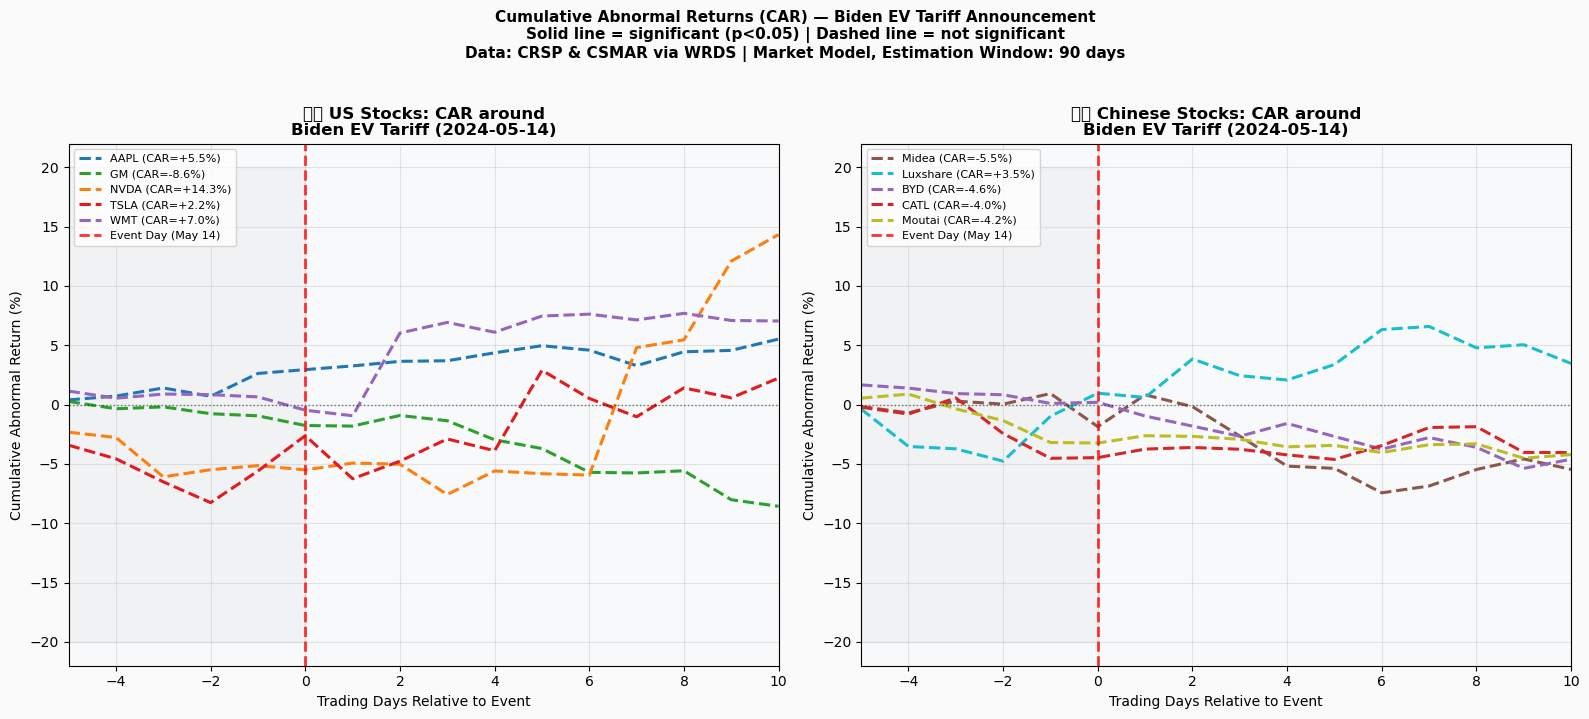

✅ CAR chart saved!


In [9]:
# =============================================================
# CAR Plot: Cumulative Abnormal Returns over event window
# 累积异常收益时间序列图
# =============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#FAFAFA')

EVENT_WINDOW = range(-5, 11)

# ---- 美股 CAR（左图）----
us_colors = {
    'AAPL': '#1f77b4',
    'NVDA': '#ff7f0e',
    'TSLA': '#e41a1c',
    'GM':   '#2ca02c',
    'WMT':  '#9467bd'
}

for ticker, r in us_results.items():
    car_series = r['AR'].cumsum() * 100
    style = '-' if r['significant'] else '--'
    ax1.plot(list(EVENT_WINDOW),
             car_series.values,
             label=f"{ticker} "
                   f"(CAR={r['CAR']*100:+.1f}%)",
             color=us_colors[ticker],
             linewidth=2.2,
             linestyle=style)

ax1.axvline(0, color='red', linestyle='--',
            linewidth=2, alpha=0.8,
            label='Event Day (May 14)')
ax1.axhline(0, color='black', linestyle=':',
            linewidth=1, alpha=0.5)
ax1.fill_betweenx([-20, 20], -5, 0,
                   alpha=0.05, color='gray')
ax1.set_title('🇺🇸 US Stocks: CAR around\n'
              'Biden EV Tariff (2024-05-14)',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Trading Days Relative to Event',
               fontsize=10)
ax1.set_ylabel('Cumulative Abnormal Return (%)',
               fontsize=10)
ax1.legend(fontsize=8, loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-5, 10)
ax1.set_facecolor('#F8F9FA')

# ---- 中股 CAR（右图）----
cn_colors = {
    '300750': '#d62728',
    '002594': '#9467bd',
    '000333': '#8c564b',
    '002475': '#17becf',
    '600519': '#bcbd22'
}

for stkcd, r in cn_results.items():
    name = cn_labels.get(stkcd, stkcd)
    car_series = r['AR'].cumsum() * 100
    style = '-' if r['significant'] else '--'
    ax2.plot(list(EVENT_WINDOW),
             car_series.values,
             label=f"{name} "
                   f"(CAR={r['CAR']*100:+.1f}%)",
             color=cn_colors.get(stkcd, 'gray'),
             linewidth=2.2,
             linestyle=style)

ax2.axvline(0, color='red', linestyle='--',
            linewidth=2, alpha=0.8,
            label='Event Day (May 14)')
ax2.axhline(0, color='black', linestyle=':',
            linewidth=1, alpha=0.5)
ax2.fill_betweenx([-20, 20], -5, 0,
                   alpha=0.05, color='gray')
ax2.set_title('🇨🇳 Chinese Stocks: CAR around\n'
              'Biden EV Tariff (2024-05-14)',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Trading Days Relative to Event',
               fontsize=10)
ax2.set_ylabel('Cumulative Abnormal Return (%)',
               fontsize=10)
ax2.legend(fontsize=8, loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-5, 10)
ax2.set_facecolor('#F8F9FA')

plt.suptitle(
    'Cumulative Abnormal Returns (CAR) — '
    'Biden EV Tariff Announcement\n'
    'Solid line = significant (p<0.05) | '
    'Dashed line = not significant\n'
    'Data: CRSP & CSMAR via WRDS | '
    'Market Model, Estimation Window: 90 days',
    fontsize=11, fontweight='bold', y=1.02)

plt.tight_layout()

img_dir = os.path.expanduser(
    '~/Desktop/tariff-shock-tracker/'
    'assets/screenshots')
os.makedirs(img_dir, exist_ok=True)
plt.savefig(f'{img_dir}/car_analysis.png',
            dpi=180, bbox_inches='tight',
            facecolor='#FAFAFA')
plt.show()
print("✅ CAR chart saved!")
